In [13]:
%matplotlib inline
import sys
import pathlib as pl
import geopandas as gpd
import numpy as np
import xugrid
from gdptools import WeightGenP2P

In [14]:
sys.path.append("../common")
from liss_settings import (
    cx,
    cx_provider,
    get_dflow_control_path,
    get_dflow_grid_name,
    get_modflow_coupling_tag,
    get_modflow_grid_name,
)

In [15]:
domain = "gp"
resolution = "high"
boundary_condition = "chd"

In [16]:
control_path = pl.Path("../dflow-fm/coarse/tides/base/FlowFM.mdu") # change this if using a different D-Flow FM control file
print(control_path)
grid_name = get_dflow_grid_name(control_path)
print(grid_name)

..\dflow-fm\coarse\tides\base\FlowFM.mdu
LIS_LowRES_012026_net


In [17]:
mf_grid_name = get_modflow_grid_name(
    domain=domain,
    boundary_condition=boundary_condition,
)
print(mf_grid_name)

gp_chd


In [18]:
get_modflow_coupling_tag(1.0)

'01.00H'

## Read the D-Flow FM output file

Make sure you run D-Flow FM by itself first so that there is an output NetCDF file available so that the mapping is done using the internal node order

In [19]:
# use an output file because this is what will be available from bmi and is in the correct order
source_path = control_path.parent / "FlowFM_map.nc"
source_ds = xugrid.open_dataset(source_path)

In [20]:
source_ds

<xarray.Dataset> Size: 53MB
Dimensions:                      (mesh2d_nNodes: 3600, mesh2d_nEdges: 10095,
                                  mesh2d_nFaces: 6491,
                                  mesh2d_nMax_face_nodes: 5, time: 54)
Coordinates:
    mesh2d_node_x                (mesh2d_nNodes) float64 29kB ...
    mesh2d_node_y                (mesh2d_nNodes) float64 29kB ...
    mesh2d_edge_x                (mesh2d_nEdges) float64 81kB ...
    mesh2d_edge_y                (mesh2d_nEdges) float64 81kB ...
    mesh2d_face_x                (mesh2d_nFaces) float64 52kB ...
    mesh2d_face_y                (mesh2d_nFaces) float64 52kB ...
  * time                         (time) datetime64[ns] 432B 2010-01-01 ... 20...
  * mesh2d_nEdges                (mesh2d_nEdges) int64 81kB 0 1 ... 10093 10094
  * mesh2d_nFaces                (mesh2d_nFaces) int64 52kB 0 1 2 ... 6489 6490
  * mesh2d_nNodes                (mesh2d_nNodes) int64 29kB 0 1 2 ... 3598 3599
Dimensions without coordinates: mesh2d_nMax_face_nodes
Data variables: (12/23)
    projected_coordinate_system  int32 4B ...
    mesh2d_node_z                (mesh2d_nNodes) float64 29kB ...
    mesh2d_face_x_bnd            (mesh2d_nFaces, mesh2d_nMax_face_nodes) float64 260kB ...
    mesh2d_face_y_bnd            (mesh2d_nFaces, mesh2d_nMax_face_nodes) float64 260kB ...
    mesh2d_edge_type             (mesh2d_nEdges) float64 81kB ...
    mesh2d_flowelem_ba           (mesh2d_nFaces) float64 52kB ...
    ...                           ...
    mesh2d_q1                    (time, mesh2d_nEdges) float64 4MB ...
    mesh2d_viu                   (time, mesh2d_nEdges) float64 4MB ...
    mesh2d_diu                   (time, mesh2d_nEdges) float64 4MB ...
    mesh2d_taus                  (time, mesh2d_nFaces) float64 3MB ...
    mesh2d_czs                   (time, mesh2d_nFaces) float64 3MB ...
    mesh2d_czu                   (time, mesh2d_nEdges) float64 4MB ...
Attributes:
    institution:    Deltares
    references:     http://www.deltares.nl
    source:         D-Flow FM 1.2.123.69078M. Model:
    history:        Created on 2026-05-19T10:25:29-0400, D-Flow FM
    date_created:   2026-05-19T10:25:29-0400
    date_modified:  2026-05-19T10:25:29-0400
    Conventions:    CF-1.8 UGRID-1.0 Deltares-0.10

In [21]:
print(source_ds.grid.face_node_connectivity.shape)
source_ds.grid.face_node_connectivity

(6491, 5)


array([[   1,    2,    0, -999, -999],
       [   1,    0,    3, -999, -999],
       [   4,    2,    1, -999, -999],
       ...,
       [3528, 3527, 3530, 3598, -999],
       [3529, 3531, 3527, 3524, -999],
       [3531, 3599, 3530, 3527, -999]], dtype=int64)

In [22]:
print(source_ds.grid.node_face_connectivity.shape)
source_ds.grid.node_face_connectivity

(3600, 6491)


<3600x6491 sparse matrix of type '<class 'numpy.int32'>'
	with 19556 stored elements in Compressed Sparse Row format>

### Convert the NetCDF data to a geodataframe

In [23]:
source_gdf = source_ds["mesh2d_nFaces"].ugrid.to_geodataframe(name="cell")

In [24]:
source_gdf.set_crs(32618, inplace=True)

,cell,mesh2d_face_x,mesh2d_face_y,geometry
mesh2d_nFaces,,,,
0,0,797898.154301,4.586507e+06,"POLYGON ((796404.975 4587306.686, 797841.614 4..."
1,1,797924.131967,4.588199e+06,"POLYGON ((796404.975 4587306.686, 799415.174 4..."
2,2,796394.352412,4.585640e+06,"POLYGON ((795260.176 4584419.699, 797841.614 4..."
3,3,799053.495508,4.585764e+06,"POLYGON ((797841.614 4584814.613, 800431.665 4..."
4,4,796629.376272,4.584104e+06,"POLYGON ((795260.176 4584419.699, 796708.901 4..."
...,...,...,...,...
6486,6486,591402.468816,4.551570e+06,"POLYGON ((589715.163 4549828.040, 592370.304 4..."
6487,6487,593237.204364,4.547120e+06,"POLYGON ((594377.970 4545125.166, 595025.445 4..."
6488,6488,591856.393641,4.555221e+06,"POLYGON ((590265.916 4553488.914, 593058.725 4..."


## Open the shapefile with the location of the coastal boundaries in MODFLOW

The shapefile needs to be limited to coastal boundary locations and be in the same coordinate system as the D-Flow FM model (UTM 18N).

In [25]:
fpth = f"../modflow/gis/{domain}/{mf_grid_name}_{boundary_condition}_surface_utm18n.shp"
print(fpth)

../modflow/gis/gp/gp_chd_chd_surface_utm18n.shp


In [26]:
target_coastal = gpd.read_file(
    fpth
)  # this is the shapefile with coastal boundary conditions
target_coastal

,head,salinity,boundname,layer,row,column,chd_no,geometry
0,0.234,35.000,perimeter-heads,0,1,45,0,"POLYGON ((722326.817 4558416.162, 722471.225 4..."
1,0.234,35.000,perimeter-heads,0,2,47,1,"POLYGON ((722664.418 4558369.322, 722808.827 4..."
2,0.234,35.000,perimeter-heads,0,3,51,2,"POLYGON ((723290.839 4558420.057, 723435.248 4..."
3,0.234,35.000,perimeter-heads,0,4,52,3,"POLYGON ((723484.032 4558324.428, 723628.442 4..."
4,0.234,35.000,perimeter-heads,0,5,53,4,"POLYGON ((723677.226 4558228.799, 723821.636 4..."
...,...,...,...,...,...,...,...,...
686,0.234,27.119,surface-heads,0,46,17,686,"POLYGON ((720478.455 4550551.416, 720622.866 4..."
687,0.234,27.119,surface-heads,0,46,18,687,"POLYGON ((720622.866 4550600.197, 720767.278 4..."
688,0.234,27.119,surface-heads,0,46,19,688,"POLYGON ((720767.278 4550648.978, 720911.690 4..."
689,0.234,27.119,surface-heads,0,46,20,689,"POLYGON ((720911.690 4550697.759, 721056.102 4..."


In [27]:
target_coastal.crs

<Projected CRS: EPSG:32618>
Name: WGS 84 / UTM zone 18N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 78°W and 72°W, northern hemisphere between equator and 84°N, onshore and offshore. Bahamas. Canada - Nunavut; Ontario; Quebec. Colombia. Cuba. Ecuador. Greenland. Haiti. Jamaica. Panama. Turks and Caicos Islands. United States (USA). Venezuela.
- bounds: (-78.0, 0.0, -72.0, 84.0)
Coordinate Operation:
- name: UTM zone 18N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

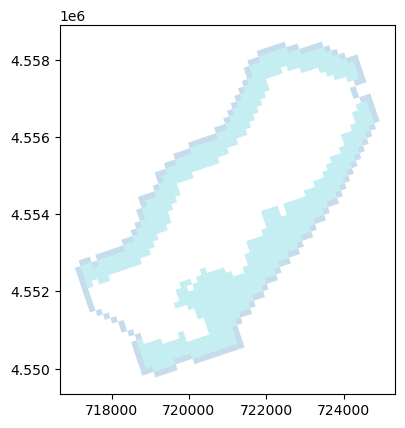

In [29]:
ax = target_coastal.plot(alpha=0.25, column="boundname")
#cx.add_basemap(ax, crs=target_coastal.crs, attribution=False, source=cx_provider)

## Create the D-FLOW FM to CHD mapping

In [30]:
# generate the weights
weight_gen = WeightGenP2P(
    target_poly=target_coastal,
    target_poly_idx="chd_no",
    source_poly=source_gdf,
    source_poly_idx=["cell"],
    method="serial",
    weight_gen_crs=32618,
)
weights = weight_gen.calculate_weights()

Using serial engine
Reprojecting to epsg:EPSG:32618 finished in 0.0 second(s)
Validating polygons
     - validating source polygons
     - fixing 0 invalid polygons.
     - validating target polygons
     - fixing 0 invalid polygons.
Validate polygons finished in 0.0116 seconds
Intersections finished in 0.0209 seconds
Weight gen finished in 0.0330 seconds


In [31]:
weights[:12]

,chd_no,cell,wght
0,0,1609,1.00000
1,1,1609,1.00000
2,2,1557,1.00000
3,3,1557,1.00000
4,4,1557,1.00000
5,5,1557,0.46944
6,5,1506,0.53056
7,6,1506,1.00000
8,7,1506,1.00000
9,8,1506,1.00000


In [32]:
map_shape = (target_coastal.shape[0], source_gdf.shape[0])
map_shape

(691, 6491)

In [33]:
dflow2mfchd = np.zeros(map_shape, dtype=float)
print(f"{dflow2mfchd.shape}\n{dflow2mfchd}")

(691, 6491)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [34]:
for r, c, v in zip(weights["chd_no"], weights["cell"], weights["wght"]):
    dflow2mfchd[int(r), int(c)] = v

## Create the chd masking array

Where the sums of the weights along a row are not equal to ~1.0

In [35]:
mask_idx = np.isclose(dflow2mfchd.sum(axis=1), 1.0)
print(f"{mask_idx.sum()}\n{mask_idx.shape}\n{mask_idx}")

691
(691,)
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  Tr

### Test the D-FLOW FM to CHD mapping

In [36]:
s = np.full(source_gdf.shape[0], 1.0)
h = np.full(mask_idx.shape, 2.0)
h[mask_idx] = dflow2mfchd.dot(s)[mask_idx]
s.shape, dflow2mfchd.shape, h.shape

((6491,), (691, 6491), (691,))

In [37]:
print(f"{h.sum()}\n{h}")

690.999999999997
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 

#### Test with a nan

In [38]:
s = np.random.random(source_gdf.shape[0])
s[1544] = -1e30
print(s)

[0.07105266 0.43838861 0.12487538 ... 0.0545108  0.39818091 0.63481363]


In [39]:
h = np.full(mask_idx.shape, 2.0)
h = dflow2mfchd.dot(s)
h.shape

(691,)

In [40]:
print(f"{h.sum()}\n{h}")

293.03902233224846
[0.20931453 0.20931453 0.87650452 0.87650452 0.87650452 0.60790571
 0.3702489  0.3702489  0.3702489  0.3702489  0.3702489  0.7159804
 0.73399417 0.3702489  0.3702489  0.36402472 0.18365847 0.15356936
 0.34872344 0.84132368 0.84132368 0.84132368 0.84132368 0.84132368
 0.9206964  0.84132368 0.84132368 0.84132368 0.84132368 0.84132368
 0.8541407  0.97509457 0.58663939 0.58663939 0.58663939 0.58663939
 0.58663939 0.58663939 0.58663939 0.58663939 0.58663939 0.60185109
 0.55322073 0.55322073 0.55322073 0.55322073 0.55322073 0.00629046
 0.55322073 0.20931453 0.20931453 0.20931453 0.21377868 0.48111582
 0.48111582 0.48111582 0.44401376 0.07366371 0.07366371 0.07366371
 0.07366371 0.11571634 0.1290148  0.1290148  0.1290148  0.1290148
 0.28115421 0.57414006 0.57414006 0.57414006 0.57414006 0.57414006
 0.6074655  0.9206964  0.9206964  0.9206964  0.9206964  0.9206964
 0.88165035 0.71615018 0.71615018 0.71615018 0.71615018 0.71615018
 0.71615018 0.71615018 0.61902676 0.05779918 0

## Create the CHD to Qext mapping

In [41]:
chd2qext = np.transpose(dflow2mfchd.copy())

### Test the CHD to Qext mapping

In [42]:
q = np.full(chd2qext.shape[1], 1.0)

In [43]:
qext = chd2qext.dot(q)

In [44]:
print(f"{qext.sum()}\n{qext.shape}")

690.999999999997
(6491,)


## Save the mapping arrays

In [45]:
fpath = (
    f"../mapping/{domain}/dflow_{grid_name}_to_{mf_grid_name}_{boundary_condition}.npz"
)
np.savez_compressed(fpath, dflow2mfchd=dflow2mfchd, chdmask=mask_idx, chd2qext=chd2qext)

In [46]:
fpath

'../mapping/gp/dflow_LIS_LowRES_012026_net_to_gp_chd_chd.npz'